# NOVA 4a/4b subdivision

Is NOVA 4 internally homogeneous, or does it contain a meaningful subdivision between products that use predominantly natural additives versus those built around synthetic ones?

In [129]:

# Loading packages
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from huggingface_hub import hf_hub_download
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# for SHAP analysis
%pip install shap
import shap


Note: you may need to restart the kernel to use updated packages.


In [130]:
# Load data - REMEMBER TO CHANGE YOUR WORKING DIRECTORY
with open("/Users/sofiebojgaardthomsen/Documents/Data_Science/DataScience2026/token.txt", "r") as f:
    token = f.read().strip()


In [131]:
# Download the raw file
path = hf_hub_download(
    repo_id="MattiWhen/ImputedNovaOpenFoodFacts",
    filename="with_imputed_nova.parquet",  # adjust filename if different
    repo_type="dataset",
    token=token
)

df_train = pd.read_parquet(path)

In [132]:
# making the nova group 4 data 
df_nova4 = df_train[df_train['nova_group'] == 4].copy()

# Inspect data
df_nova4.head()

,product_name,brands,nova_group,nutriscore_score,nutriscore_grade,lang,languages_tags,ingredients_original_tags,code,product_name_clean,...,has_synthetic_only,has_natural_only,emulsifier_count,preservative_count,sweetener_count,colorant_count,ingredient_count,nova_mord,nova_lgbm,model_agreement
20,"[{'lang': 'main', 'text': 'outdoor bred unsmok...",Coop,4.0,22.0,e,en,"[en:english, en:1]","[en:noked-rindless-back-n-with-added-er, en:28...",5000129329193,outdoor bred unsmoked back bacon,...,0,0,0,2,0,0,17,4.0,2.0,False
149,"[{'lang': 'main', 'text': 'Popcorn Seasoning B...",Yoder Popcorn,4.0,20.0,e,en,"[en:english, en:1]","[en:salt, en:certified-food-color, en:imitatio...",0038637140028,Popcorn Seasoning Buttery Salt,...,0,0,0,0,0,0,3,4.0,2.0,False
169,"[{'lang': 'main', 'text': 'Seafood selection'}...",Marks and spencer,4.0,-2.0,a,en,"[en:english, en:1]","[en:mussel-meat, en:king-prawns, en:squid, en:...",29150168,Seafood selection,...,0,0,0,0,0,0,11,4.0,2.0,False
176,"[{'lang': 'main', 'text': 'Mature cheddar & re...",Dettol,4.0,14.0,d,en,"[en:english, en:1]",[en:peciall-selected-made-with-british-potatoe...,4088600007861,Mature cheddar & red onion hand cooked crisps,...,0,0,0,0,0,0,10,4.0,2.0,False
182,"[{'lang': 'main', 'text': 'Sourdough Cob'}, {'...",The Breadski Brothers,4.0,6.0,c,en,"[en:english, en:1]","[en:wheat-flour, en:rye-flour, en:salt, en:bak...",5391515795167,Sourdough Cob,...,0,1,0,0,0,0,24,4.0,2.0,False


In [133]:
print(df_nova4.columns.tolist())

['product_name', 'brands', 'nova_group', 'nutriscore_score', 'nutriscore_grade', 'lang', 'languages_tags', 'ingredients_original_tags', 'code', 'product_name_clean', 'product_ID', 'ingredients_parsed', 'ingredients_clean', 'additive_count', 'has_additive', 'natural_additive_count', 'synthetic_additive_count', 'debated_additive_count', 'has_synthetic', 'has_natural', 'has_synthetic_only', 'has_natural_only', 'emulsifier_count', 'preservative_count', 'sweetener_count', 'colorant_count', 'ingredient_count', 'nova_mord', 'nova_lgbm', 'model_agreement']


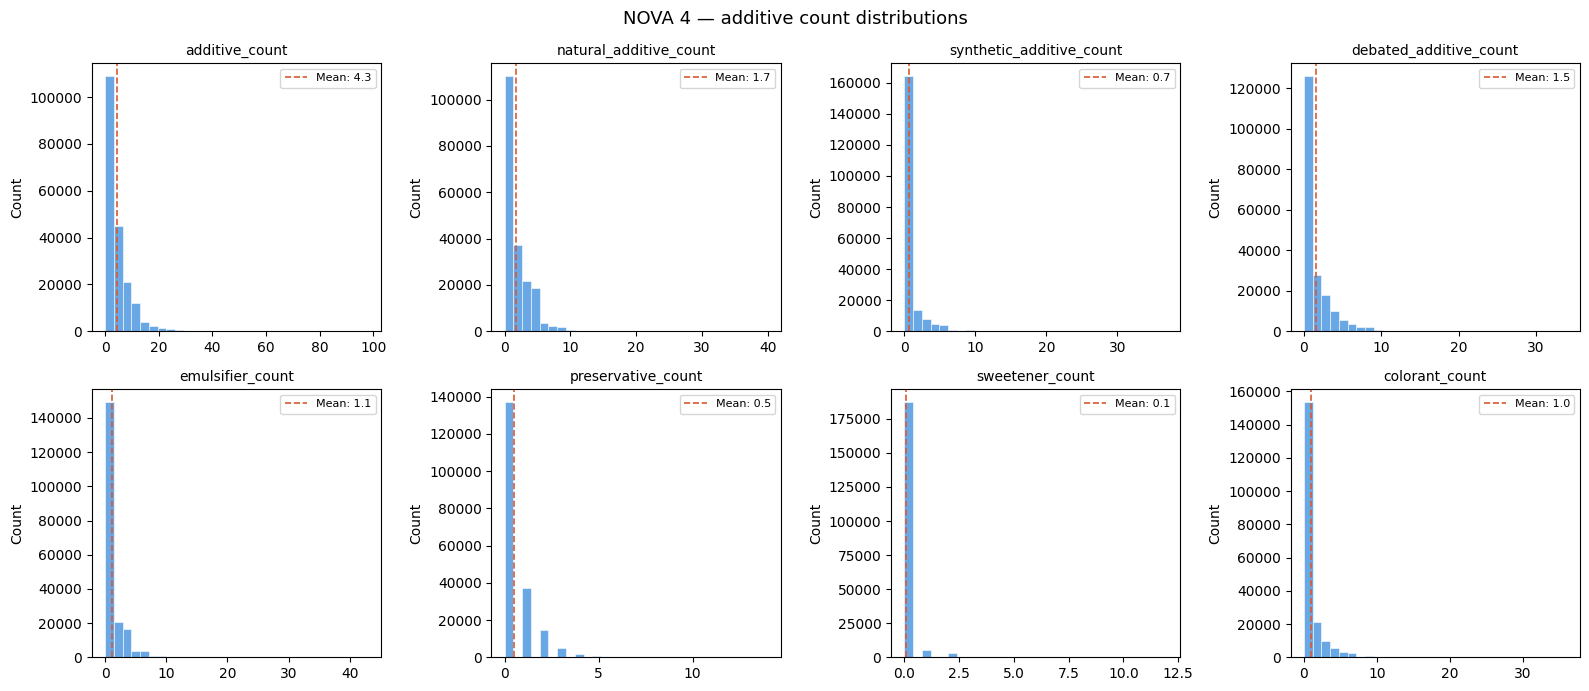

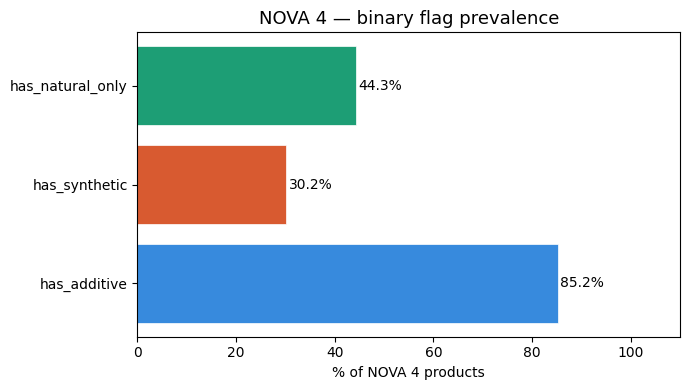

In [135]:
# investigate 
# 'nutriscore_score', 'nutriscore_grade', 'additive_count', 'has_additive', 'natural_additive_count', 'synthetic_additive_count', 'debated_additive_count', 'has_synthetic', 'has_natural', 'has_synthetic_only', 'has_natural_only', 'emulsifier_count', 'preservative_count', 'sweetener_count', 'colorant_count'
count_cols = [
    'additive_count', 'natural_additive_count', 'synthetic_additive_count',
    'debated_additive_count', 'emulsifier_count', 'preservative_count',
    'sweetener_count', 'colorant_count'
]
flag_cols = ['has_additive', 'has_synthetic', 'has_natural_only']

# ── Plot 1: count distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('NOVA 4 — additive count distributions', fontsize=13)

for ax, col in zip(axes.flatten(), count_cols):
    sns.histplot(df_nova4[col], bins=30, ax=ax, color='#378ADD',
                 edgecolor='white', linewidth=0.4)
    ax.axvline(df_nova4[col].mean(), color='#D85A30', linestyle='--',
               linewidth=1.2, label=f'Mean: {df_nova4[col].mean():.1f}')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('nova4_count_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: binary flag prevalence ────────────────────────────────────────────
flag_pct = df_nova4[flag_cols].mean() * 100  # % of products where flag == 1

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(flag_pct.index, flag_pct.values,
               color=['#378ADD', '#D85A30', '#1D9E75'],
               edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10)

ax.set_xlabel('% of NOVA 4 products')
ax.set_xlim(0, 110)
ax.set_title('NOVA 4 — binary flag prevalence', fontsize=13)
plt.tight_layout()
plt.savefig('nova4_flag_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

these distributions suggest your NOVA 4 population is dominated by mildly processed products with a long tail of heavily reformulated ones. That tail is likely where your 4b cluster will emerge. It might be worth considering whether to log-transform the count features before running KMeans in 9.2, since the heavy skew and outliers can distort distance-based clustering

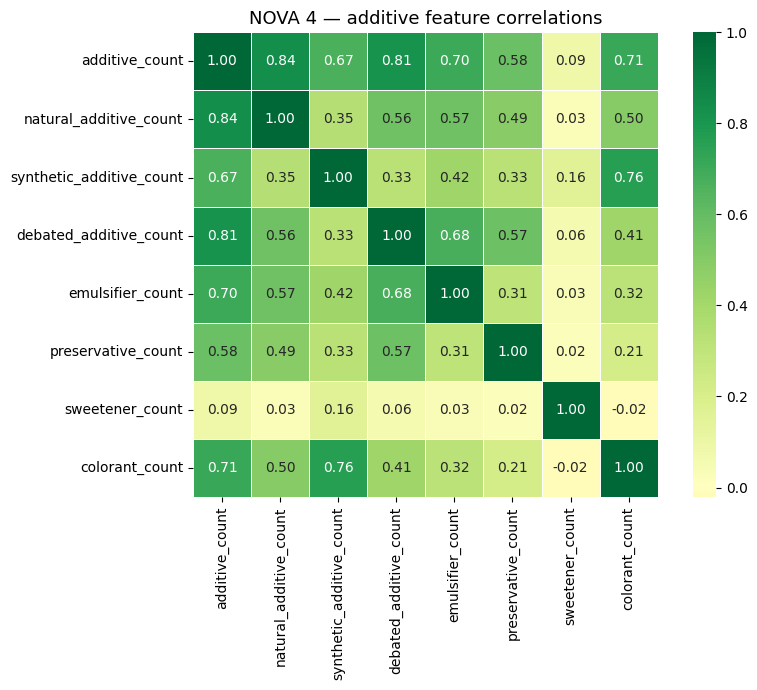

In [136]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df_nova4[count_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('NOVA 4 — additive feature correlations', fontsize=13)
plt.tight_layout()
plt.savefig('nova4_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

sweetener_count stands alone!
It has near-zero correlation with almost everything — 0.14 with additive_count, and even slightly negative (-0.02) with colorant_count. This suggests sweeteners are a fairly independent feature — products that use sweeteners don't necessarily use more additives overall. This is actually useful for your 4a/4b split, as sweeteners (often synthetic, like aspartame or acesulfame-K) may be a clean signal on their own.


synthetic_additive_count and colorant_count are strongly linked (0.79)
This is one of the most interesting findings — synthetic additives and colorants tend to co-occur heavily. This makes intuitive sense: industrial products that use synthetic colors (think bright breakfast cereals, candy, soft drinks) tend to be heavily reformulated overall. This directly supports your 4b "industrially reformulated" cluster.

natural_additive_count is more loosely correlated with everything
It correlates moderately with additive_count (0.83, expected since it's a component of it) but relatively weakly with synthetic_additive_count (0.31), suggesting natural and synthetic additives genuinely appear in different products rather than just stacking on top of each other. Good news for the 4a/4b split.

emulsifier_count and debated_additive_count are moderately linked (0.67)
This makes sense because many emulsifiers (like carrageenan E407, lecithin E322) fall in the debated/ambiguous category — they're exactly the contested cases your project acknowledges in Phase 9.6.

# 9.2 - KMeans
KMeans will look at all your additive feature columns for each product and try to find 2 groups that are naturally similar within themselves and different from each other. You're not telling it what the groups mean — it just finds the split.

Why k=2
The phases document specifies it because your hypothesis is exactly two groups: 4a and 4b. You're not exploring how many clusters exist, you're testing whether your specific proposed split shows up in the data.

Okay, two things:
1. we want to remove all columns where there is debated additive count >0 to make a clearer distinction for the additives for the K-Means clustering
2. maybe add the ingredients (Matilda sent on text for the features)

# 5th?!?! time is a charm??
We restricted clustering features to additive-level aggregates and functional categories to preserve interpretability and avoid high-dimensional sparsity from individual additive indicators.

In [139]:
core_features = [
    'additive_count',
    'natural_additive_count',
    'synthetic_additive_count',
    'debated_additive_count'
]

binary_features = [
    'has_additive',
    'has_synthetic', # the one we later on want to remove
    'has_natural_only',
    'has_synthetic_only'
]

category_features = [
    'emulsifier_count',
    'preservative_count',
    'sweetener_count',
    'colorant_count'
]

feature_cols = core_features + binary_features + category_features

In [140]:
# ── Scale features ────────────────────────────────────────────────────────────
# KMeans is distance-based, so features must be on the same scale.
# Without scaling, variables like 'additive_count' would dominate the clustering.
scaler = StandardScaler()
X_nova4 = scaler.fit_transform(df_nova4[feature_cols])


# ── Fit KMeans clustering (k=2) ───────────────────────────────────────────────
# We set k=2 to test the hypothesis that NOVA 4 splits into two subgroups (4a / 4b).
# For writing the report we REALLY need to justify why we predict a subgroup 4a / 4b split and not more!!
    #“We hypothesise a binary distinction between products dominated by natural versus synthetic additives, which motivates k=2.”
# random_state ensures reproducibility.
# n_init=10 runs KMeans multiple times with different centroid seeds and keeps the best result.
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)

# Assign each product to one of the two clusters
df_nova4['nova4_cluster'] = kmeans.fit_predict(X_nova4)


# ── Quick sanity check: cluster sizes ─────────────────────────────────────────
# This helps verify that clustering is not degenerate (e.g. all points in one cluster).
print(df_nova4['nova4_cluster'].value_counts())

nova4_cluster
0    137150
1     59876
Name: count, dtype: int64


In [141]:
# Silhouette score
score = silhouette_score(X_nova4, df_nova4['nova4_cluster'])
print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.369


Silhouette score ranges:

~0.0 → no real structure
~0.1–0.2 → weak but usable (very common in messy data)
~0.2–0.3 → decent
>0.3 → strong clustering structure

0.5 → rare, very clean separation

Clustering produced a silhouette score of 0.357, indicating a well-defined separation in the feature space. This supports the presence of meaningful internal structure within NOVA 4, consistent with the hypothesis of a natural versus synthetic additive distinction.

due to the outputs above, we will NOT keep the has_synthetic column as it makes the silhouette score a bit lower and thus, the clusters a bit less interpretable. It also makes sense as the has_synthetic column doesn't add much more when we already have the answer in the synthetic_additive_count column (i.e. if it is >0 ).

🚨 One thing to notice (VERY interesting)

Our “industrial” cluster is only:

34,763 products (~19%)

That’s actually fascinating.

It suggests:

Most NOVA 4 products are not maximally industrialised.

This is a strong argument for your whole subdivision idea.

ALSO: 
it's less a matter of "synthetic vs. natural additives" but rather:
light additive usage vs intensive industrial reformulation

In [142]:
# Thus these are our final features
final_feature_cols = [
    'additive_count',
    'natural_additive_count',
    'synthetic_additive_count',
    'debated_additive_count',
    'has_additive',
    'has_natural_only',
    'has_synthetic_only',
    'emulsifier_count',
    'preservative_count',
    'sweetener_count',
    'colorant_count'
]

In [144]:
# ── Scale features ────────────────────────────────────────────────────────────
# KMeans is distance-based, so features must be on the same scale.
# Without scaling, variables like 'additive_count' would dominate the clustering.
scaler = StandardScaler()
X_nova4 = scaler.fit_transform(df_nova4[final_feature_cols])


# ── Fit KMeans clustering (k=2) ───────────────────────────────────────────────
# We set k=2 to test the hypothesis that NOVA 4 splits into two subgroups (4a / 4b).
# For writing the report we REALLY need to justify why we predict a subgroup 4a / 4b split and not more!!
    #“We hypothesise a binary distinction between products dominated by natural versus synthetic additives, which motivates k=2.”
# random_state ensures reproducibility.
# n_init=10 runs KMeans multiple times with different centroid seeds and keeps the best result.
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)

# Assign each product to one of the two clusters
df_nova4['nova4_cluster'] = kmeans.fit_predict(X_nova4)


# ── Quick sanity check: cluster sizes ─────────────────────────────────────────
# This helps verify that clustering is not degenerate (e.g. all points in one cluster).
print(df_nova4['nova4_cluster'].value_counts())

nova4_cluster
0    164507
1     32519
Name: count, dtype: int64


In [145]:
# Silhouette score
score = silhouette_score(X_nova4, df_nova4['nova4_cluster'])
print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.414


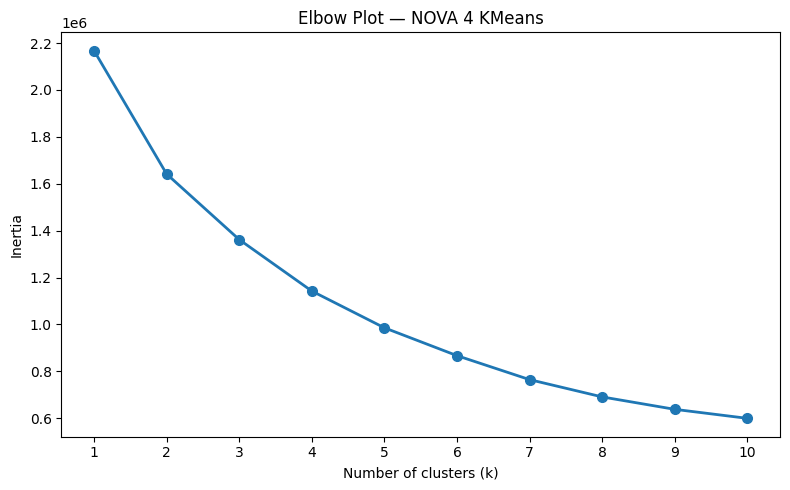

In [152]:
# ── Compute inertia values for different k ────────────────────────────────────
inertias = []
k_range = range(1, 11)

for k in k_range:
    km4 = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km4.fit(X_nova4)

    # Inertia = within-cluster sum of squared distances
    inertias.append(km4.inertia_)


# ── Plot elbow curve ──────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))

plt.plot(
    k_range,
    inertias,
    marker='o',
    linewidth=2,
    markersize=7
)

plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot — NOVA 4 KMeans')

plt.xticks(k_range)

plt.tight_layout()

plt.savefig(
    'nova4_elbow.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

“The elbow plot indicated diminishing returns in within-cluster variance reduction after the initial clusters, with the largest decrease occurring between k=1 and k=2. Although additional clusters further reduced inertia, k=2 was selected based on a combination of theoretical motivation, silhouette score, and interpretability.”

In [153]:
# Inspect cluster centers
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=final_feature_cols
)

print(cluster_centers)

   additive_count  natural_additive_count  synthetic_additive_count  \
0        2.733927                1.200523                  0.329357   
1       12.505403                4.387026                  2.757212   

   debated_additive_count  has_additive  has_natural_only  has_synthetic_only  \
0                0.956802      0.822863          0.491878            0.051311   
1                4.385949      1.000000          0.194483            0.010929   

   emulsifier_count  preservative_count  sweetener_count  colorant_count  
0          0.629846            0.289404         0.062949        0.569334  
1          3.346972            1.501339         0.147225        3.045781  


# Nutri-score validation

In [154]:
pd.crosstab(
    df_nova4['nova4_cluster'],
    df_nova4['nutriscore_grade'],
    normalize='index'
)

nutriscore_grade,a,b,c,d,e
nova4_cluster,,,,,
0,0.083741,0.087796,0.200624,0.251229,0.37661
1,0.028414,0.030721,0.186107,0.327009,0.42775


In [155]:
df_nova4.groupby('nova4_cluster')[[
    'additive_count',
    'synthetic_additive_count',
    'emulsifier_count',
    'colorant_count'
]].mean()

,additive_count,synthetic_additive_count,emulsifier_count,colorant_count
nova4_cluster,,,,
0,2.732802,0.329208,0.629140,0.569198
1,12.499677,2.755128,3.347366,3.043575


“NOVA 4 products are not internally homogeneous. Clustering revealed a subgroup characterised by low additive density and limited synthetic additive use (NOVA 4a), and a subgroup characterised by extensive additive complexity and high synthetic additive burden (NOVA 4b). These groups also differ in Nutri-Score distribution, with the industrially reformulated subgroup containing substantially more E-grade products.” 

++++ the best clustering was without the has_synthetic column. 

# LightGBM
Cluster assignments from KMeans were used as pseudo-labels for supervised classification.

In [156]:
# Define x and y
X = df_nova4[final_feature_cols]
y = df_nova4['nova4_cluster']

Then we retained the same split strategy as the main NOVA classification pipeline.

In [157]:
# First split: train+val vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, # input features, e.g. additive counts, synthetic counts, emulsifier counts
    y, # target labels, here nova4_cluster, meaning 4a vs 4b
    test_size=0.2, # Uses 20% of the products as a held-out test set and 80% for training and validation for the second split.
    stratify=y, # Keeps the same proportion of cluster 0 and cluster 1 in both train and test.
    random_state=42 # Makes the split reproducible, so we get the same train/test split every time we run it.
)

# Second split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,  # 0.125 * 0.8 = 0.10 total (which is what we want)
    stratify=y_train_val,
    random_state=42
)

print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

Train: 137917
Val:   19703
Test:  39406


In [158]:
# Train LightGBM

# ── Define binary LightGBM model for NOVA 4a vs 4b ────────────────────────────
model_4ab = lgb.LGBMClassifier(
    objective='binary',        # binary classification: cluster 0 vs cluster 1
    n_estimators=300,          # maximum number of boosting trees
    learning_rate=0.05,        # smaller learning rate = slower but often more stable learning
    num_leaves=31,             # controls tree complexity
    class_weight='balanced',   # compensates for imbalance between 4a and 4b clusters
    random_state=42
)

# ── Fit model on training data and evaluate during training on validation data ─
model_4ab.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='binary_logloss'
)

[LightGBM] [Info] Number of positive: 22763, number of negative: 115154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 202
[LightGBM] [Info] Number of data points in the train set: 137917, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [159]:
# Evaluate predictions
y_val_pred = model_4ab.predict(X_val)
y_val_prob = model_4ab.predict_proba(X_val)[:, 1]

# Evaluate metrics
print("Validation AUC-ROC:", roc_auc_score(y_val, y_val_prob))
print("Validation F1:", f1_score(y_val, y_val_pred))
print("\nValidation classification report:")
print(classification_report(y_val, y_val_pred))
print("\nValidation confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))

Validation AUC-ROC: 0.9999604849856778
Validation F1: 0.9864885380294519

Validation classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     16451
           1       0.97      1.00      0.99      3252

    accuracy                           1.00     19703
   macro avg       0.99      1.00      0.99     19703
weighted avg       1.00      1.00      1.00     19703


Validation confusion matrix:
[[16365    86]
 [    3  3249]]


Expect this:
You’ll probably get:

very high AUC (>0.9??)
strong F1

because your clusters are already well-separated.

# SHAP Analysis

How the model predicts:
0 = NOVA 4a (cosmetically processed)
1 = NOVA 4b (industrially reformulated)

Here, SHAP explains which features push products toward 4a vs 4b.^

In [160]:
# SHAP Analysis

# Create SHAP explainer
explainer = shap.TreeExplainer(model_4ab)

# Calculate SHAP values
shap_values = explainer.shap_values(X_val)

/Users/sofiebojgaardthomsen/Documents/Data_Science/DataScience2026/env/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


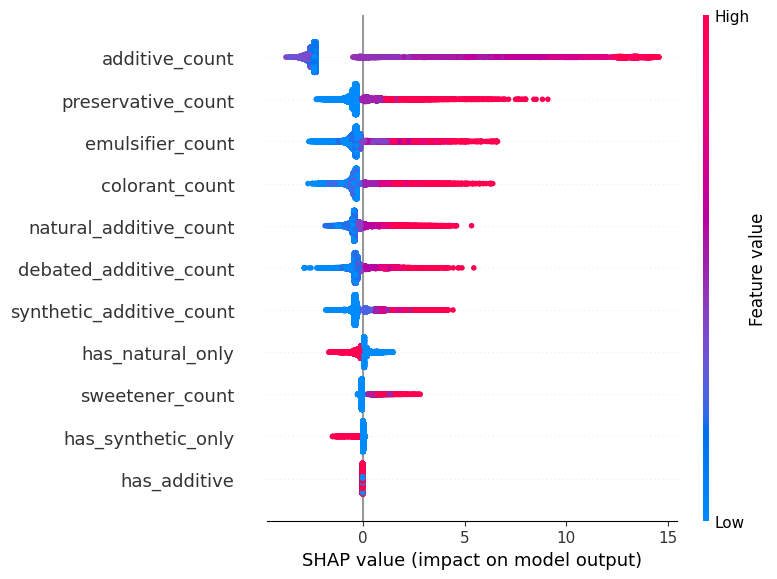

In [161]:
# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_val,
    feature_names=final_feature_cols
)

The beeswarm plot should be read as:
on the x-axis, we have:
positive → pushes prediction toward 4b
negative → pushes prediction toward 4a

and the color:
blue = low feature value
pink/red = high feature value

# Additive count is overwhelmingly dominant
high additive counts (red points)
→ strongly positive SHAP
→ push products toward 4b
low additive counts (blue points)
→ negative SHAP
→ push toward 4a
THUS, the strongest separator inside NOVA 4 is overall additive complexity.
So it's not whether it contains synthetic additives, but rather the degree of industrial reformulation. 

# Preservatives, colorants, emulsifiers matter a LOT

These all show the same pattern:
high values → push strongly toward 4b
low values → push toward 4a

NOVA 4b products engineered for:
- shelf stability
- texture modification
- cosmetic appearance
- industrial scalability

That’s exactly what these additive categories represent.

# synthetic_additive_count is important — but NOT the top feature

# has_natural_only pushes toward 4a

# has_additive contributes almost nothing

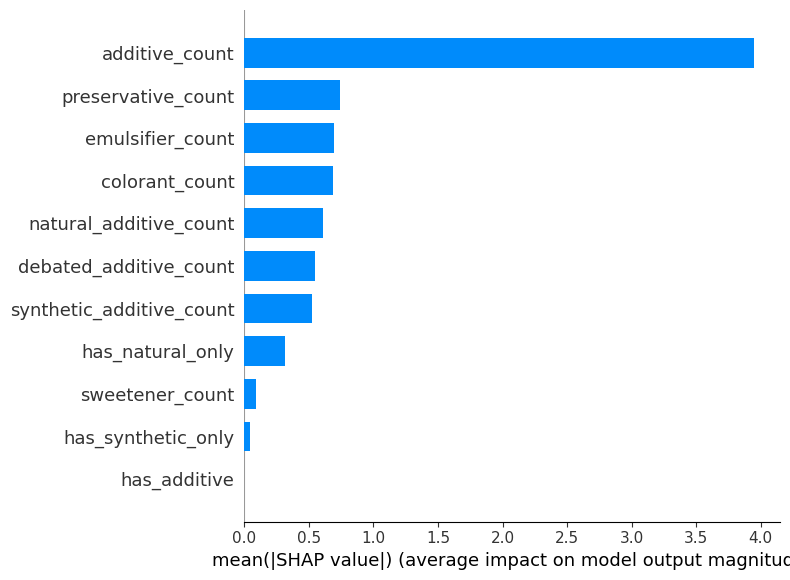

In [162]:
shap.summary_plot(shap_values, X_val, feature_names=final_feature_cols, plot_type="bar")

The SHAP bar plot shows the average absolute importance.

It answers which features matter MOST overall.

Soo, additive_count is by far the strongest driver. 

Then comes preservative_count, colorant_count and emulsifier_count. 

And then; synthetic_additive_count, natural_additive_count and debated_additive_count. 

Thus, the key distinction is additive complexity + industrial reformulation intensity..

“The proposed NOVA 4 subdivision is driven not only by synthetic additive presence, but by broader patterns of industrial reformulation characterised by high additive density and extensive use of preservatives, emulsifiers, and colorants.”

# Cluster labeel interpretation

NOVA 4a = “Cosmetically processed”
lower additive complexity
fewer industrial additive categories
more natural-only products

NOVA 4b = “Industrially reformulated”
high additive burden
strong preservative/emulsifier/colorant usage
more synthetic additives
worse Nutri-Score profile

Thus, it's no longer:
“synthetic additives define ultra-processing.”

Instead it's:
“industrial reformulation intensity defines a meaningful internal structure within NOVA 4.”